#section_1

#Mount drive,

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
FILE_PATH = '/content/drive/MyDrive/travclan_assessment/assessment_june20_2026/hotel_bookings.csv'
df = pd.read_csv(FILE_PATH, keep_default_na=False, na_values=[''])
print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(12000, 28)


,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
0,100000,424,Customer_424,Group,2023-07-03,Manali,Platinum,38,Crimson Courtyard,Manali,...,4,OTA,5808.46,0.00,NONE,46467.68,Debit Card,Cancelled,NaN,NaN
1,100001,239,Customer_239,Individual,2022-07-18,Jaipur,None,32,Saffron Palace,Pune,...,4,Corporate Portal,4021.62,0.00,NaN,16086.48,Net Banking,Cancelled,NaN,NaN
2,100002,301,Customer_301,Corporate,2023-07-05,Jaipur,Gold,53,Saffron Heights,Chennai,...,3,Corporate Portal,17663.11,15373.35,SAVE10,90605.31,Net Banking,Completed,NaN,NaN
3,100003,722,Customer_722,Individual,2022-11-07,Udaipur,None,43,Indigo Lodge,Bangalore,...,3,OTA,5885.85,0.00,NONE,17657.55,Credit Card,No-Show,NaN,NaN
4,100004,306,Customer_306,Corporate,2022-02-02,Udaipur,Silver,29,Cedar Lodge,Kochi,...,7,Direct Website,6199.44,5924.82,SAVE10,80867.34,Credit Card,Completed,6.0,2024-11-21


#Convert date columns

In [5]:
date_cols = ['booking_date', 'checkin_date', 'checkout_date', 'customer_signup_date', 'review_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

#Footnote 1: checkout on or before check-in.

In [6]:
invalid_stays = df[df['checkout_date'] <= df['checkin_date']]
a1_answer = len(invalid_stays)
print("A1:", a1_answer)

A1: 120


#A2: Review rating range and mean per segment (with normalization)

In [7]:
df['review_rating_normalized'] = df['review_rating']
corp_mask = df['customer_segment'] == 'Corporate'
df.loc[corp_mask, 'review_rating_normalized'] = df.loc[corp_mask, 'review_rating'] / 2

a2 = df.groupby('customer_segment')['review_rating_normalized'].agg(['min', 'max', 'mean', 'count'])
print(a2)

                  min  max      mean  count
customer_segment                           
Corporate         1.5  5.0  3.624320   1287
Group             1.0  5.0  3.771186    590
Individual        1.0  5.0  3.771184   3269


Corporate reviews are recorded on a 1–10 scale while Individual and Group use 1–5 (Footnote 6).
Corporate ratings were divided by 2 to bring all segments onto a common 1–5 scale before comparison.

**Implication:** Once normalized, mean satisfaction is nearly identical across all three segments (~3.6–3.8).
Without normalization, Corporate's raw mean would appear almost double the others purely due to scale,
falsely implying a segment-driven rating gap. Cross-segment averages are only valid after normalization.

In [8]:
clean = df[
    (df['checkout_date'] > df['checkin_date']) &
    (df['num_rooms'] > 0) &
    (df['booking_status'] == 'Completed')
]

luxury_revenue = clean[clean['property_type'] == 'Luxury']['total_amount'].sum()
print("A3 realized revenue (Luxury):", luxury_revenue)

A3 realized revenue (Luxury): 90694052.93


### A3 — Realized Revenue, Luxury Properties

Applied three data-quality filters before aggregating (Footnotes 1, 3, 8):
- Excluded invalid stays (checkout ≤ check-in)
- Excluded zero-room bookings (total_amount = 0, erroneous)
- Kept only booking_status = 'Completed' (Cancelled/No-Show carry a would-have-been total_amount,
  not realized revenue)

**Realized revenue (Luxury): ₹90,694,052.93**

For comparison, summing total_amount across *all* Luxury rows regardless of status gives
₹117,431,484.47 — a 29.5% overstatement, matching Footnote 8's warning almost exactly.
This confirms the filtering logic is correctly isolating realized revenue.

#section_2

#Build the lead-time and base cancellation fields

In [9]:
df['lead_time'] = (df['checkin_date'] - df['booking_date']).dt.days

def bucket_lead_time(days):
    if pd.isna(days):
        return 'Unknown'
    elif days <= 7:
        return '0-7'
    elif days <= 30:
        return '8-30'
    elif days <= 60:
        return '31-60'
    else:
        return '60+'

df['lead_time_bucket'] = df['lead_time'].apply(bucket_lead_time)

base = df[
    (df['checkout_date'] > df['checkin_date']) &
    (df['num_rooms'] > 0)
].copy()

base['is_cancelled'] = base['booking_status'] == 'Cancelled'
print(base['is_cancelled'].mean())  # overall cancellation rate, should be ~19% per the brief

0.19152355976651722


#A1: Build the two-dimension breakdown (channel × lead-time bucket)

In [10]:
landscape = base.groupby(['booking_channel', 'lead_time_bucket']).agg(
    total_bookings=('booking_id', 'count'),
    cancellations=('is_cancelled', 'sum')
).reset_index()

landscape['cancel_rate'] = landscape['cancellations'] / landscape['total_bookings']
landscape_pivot = landscape.pivot(index='booking_channel', columns='lead_time_bucket', values='cancel_rate')
print(landscape_pivot.round(3))

lead_time_bucket    0-7  31-60    60+   8-30
booking_channel                             
Corporate Portal  0.185  0.243  0.204  0.193
Direct Website    0.125  0.183  0.203  0.135
OTA               0.203  0.273  0.249  0.195
Travel Agent      0.160  0.215  0.181  0.139


#Plot the grouped bar chart (with value labels)

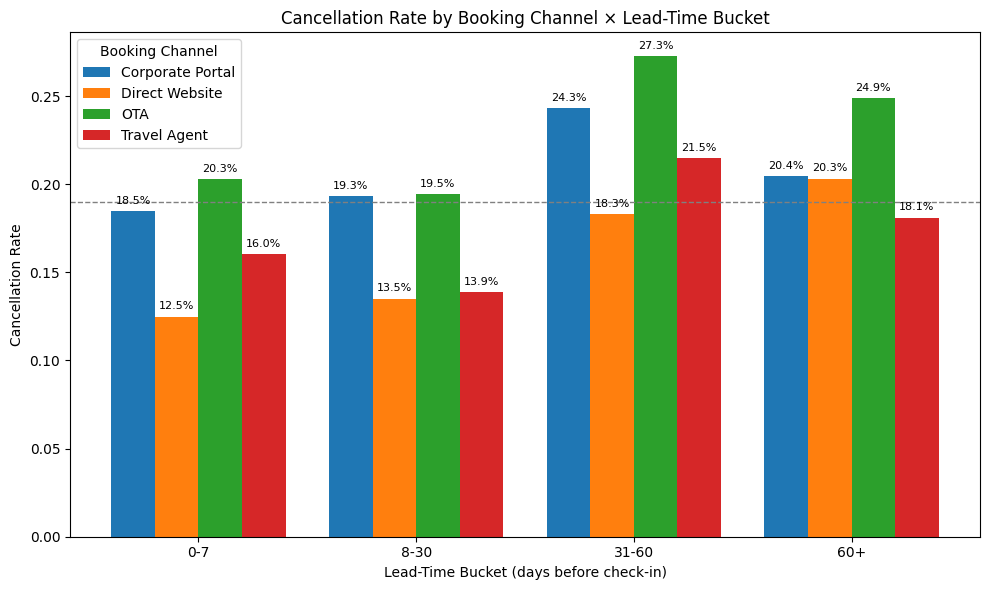

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Reorder lead-time buckets logically
bucket_order = ['0-7', '8-30', '31-60', '60+']
landscape_pivot = landscape_pivot[bucket_order]

channels = landscape_pivot.index.tolist()
x = np.arange(len(bucket_order))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, channel in enumerate(channels):
    values = landscape_pivot.loc[channel].values
    bars = ax.bar(x + i*width, values, width, label=channel)
    # value labels on top of each bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.1%}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Lead-Time Bucket (days before check-in)')
ax.set_ylabel('Cancellation Rate')
ax.set_title('Cancellation Rate by Booking Channel × Lead-Time Bucket')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(bucket_order)
ax.legend(title='Booking Channel')
ax.axhline(y=0.19, color='gray', linestyle='--', linewidth=1, label='Platform avg (19%)')
plt.tight_layout()
plt.savefig('a1_cancellation_landscape.png', dpi=150)
plt.show()

**Worst single slice:** OTA × 31-60 day lead time — 27.3% cancellation, ~8pp above platform average.
**Best single slice:** Direct Website × 0-7 day lead time — 12.5%.

**Which dimension drives more variance:** Booking channel is the dominant driver. OTA shows the highest
or near-highest rate in every lead-time bucket, and Direct Website shows the lowest in every bucket —
a consistent ordering across all four buckets, not a one-off spike. Lead-time bucket is a secondary,
amplifying factor: cancellation rate rises in the 31-60 day window across nearly all channels, peaking
there before easing slightly at 60+. Channel × the 31-60 bucket together produce the platform's worst slice.

#A2: Rank slices by rate vs by volume

In [12]:
top3_by_rate = landscape.sort_values('cancel_rate', ascending=False).head(3)
print("TOP 3 BY RATE:")
print(top3_by_rate[['booking_channel', 'lead_time_bucket', 'total_bookings', 'cancellations', 'cancel_rate']])

print()

top3_by_count = landscape.sort_values('cancellations', ascending=False).head(3)
print("TOP 3 BY COUNT:")
print(top3_by_count[['booking_channel', 'lead_time_bucket', 'total_bookings', 'cancellations', 'cancel_rate']])

TOP 3 BY RATE:
     booking_channel lead_time_bucket  total_bookings  cancellations  \
9                OTA            31-60             943            257   
10               OTA              60+             370             92   
1   Corporate Portal            31-60             675            164   

    cancel_rate  
9      0.272534  
10     0.248649  
1      0.242963  

TOP 3 BY COUNT:
   booking_channel lead_time_bucket  total_bookings  cancellations  \
11             OTA             8-30            1496            291   
8              OTA              0-7            1375            279   
9              OTA            31-60             943            257   

    cancel_rate  
11     0.194519  
8      0.202909  
9      0.272534  


### A2 — Rate vs. Volume

**Top 3 by cancellation rate:** OTA×31-60 (27.3%), OTA×60+ (24.9%), Corporate Portal×31-60 (24.3%)
**Top 3 by cancellation count:** OTA×8-30 (291 cancels), OTA×0-7 (279 cancels), OTA×31-60 (257 cancels)

Only OTA×31-60 appears on both lists. The other rate-leaders are low-volume (370 and 675 bookings),
so fixing them barely moves the platform number. The volume-leaders, by contrast, have only moderate
rates (~19-20%, near the platform average) but their sheer size (1,375-1,496 bookings each) makes them
the real source of absolute cancellations.

**Why this matters for the board's 5pp target:** A 5pp platform-wide reduction requires moving total
cancellation count, not just flattening a few extreme percentages. Targeting only the worst-rate slices
would fix ~1,045 bookings' worth of risk; targeting OTA broadly (which dominates all three count-ranked
slices, all four lead-time buckets) touches thousands of bookings and has far more leverage on the
platform-wide number, even though no single OTA bucket looks as alarming as Corporate Portal×31-60 on
a rate basis alone.

#A3: Hypothesis Testing on OTA × 31-60

In [13]:
worst_slice = base[(base['booking_channel'] == 'OTA') & (base['lead_time_bucket'] == '31-60')]
rest_of_platform = base[~((base['booking_channel'] == 'OTA') & (base['lead_time_bucket'] == '31-60'))]

print("=== HYPOTHESIS 1: Lead-time effect ===")
print("Slice lead_time stats:")
print(worst_slice['lead_time'].describe())
print()
print("Rest of platform lead_time stats:")
print(rest_of_platform['lead_time'].describe())
print()

print("=== HYPOTHESIS 2: Channel-mix effect ===")
print("Channel mix WITHIN the slice (should be 100% OTA by definition):")
print(worst_slice['booking_channel'].value_counts(normalize=True))
print()
print("Channel mix of rest of platform:")
print(rest_of_platform['booking_channel'].value_counts(normalize=True))
print()
ota_all = base[base['booking_channel'] == 'OTA']
print("OTA overall cancel rate (all lead times):", ota_all['is_cancelled'].mean())
print("OTA cancel rate specifically in 31-60 bucket:", worst_slice['is_cancelled'].mean())
print()

print("=== HYPOTHESIS 3: City-season effect ===")
print("Top cities in the slice:")
print(worst_slice['property_city'].value_counts().head(5))
print()

top_city = worst_slice['property_city'].value_counts().idxmax()
print(f"Top city in slice: {top_city}")

same_city_other_buckets = base[(base['property_city'] == top_city) & (base['booking_channel'] == 'OTA') & (base['lead_time_bucket'] != '31-60')]
print(f"{top_city} OTA cancel rate in OTHER lead-time buckets:", same_city_other_buckets['is_cancelled'].mean())

other_city_same_bucket = base[(base['property_city'] != top_city) & (base['booking_channel'] == 'OTA') & (base['lead_time_bucket'] == '31-60')]
print(f"OTA, 31-60 bucket, OTHER cities (not {top_city}) cancel rate:", other_city_same_bucket['is_cancelled'].mean())

print(f"{top_city}, OTA, 31-60 bucket (the slice itself) cancel rate:", worst_slice['is_cancelled'].mean())

=== HYPOTHESIS 1: Lead-time effect ===
Slice lead_time stats:
count    943.000000
mean      48.907741
std        9.945444
min       40.000000
25%       40.000000
50%       40.000000
75%       60.000000
max       60.000000
Name: lead_time, dtype: float64

Rest of platform lead_time stats:
count    10878.000000
mean        31.085953
std         71.874977
min          2.000000
25%          7.000000
50%         15.000000
75%         25.000000
max       1137.000000
Name: lead_time, dtype: float64

=== HYPOTHESIS 2: Channel-mix effect ===
Channel mix WITHIN the slice (should be 100% OTA by definition):
booking_channel
OTA    1.0
Name: proportion, dtype: float64

Channel mix of rest of platform:
booking_channel
OTA                 0.297941
Corporate Portal    0.290495
Travel Agent        0.218882
Direct Website      0.192682
Name: proportion, dtype: float64

OTA overall cancel rate (all lead times): 0.21964627151051624
OTA cancel rate specifically in 31-60 bucket: 0.2725344644750795

=== HYPO

### A3 — Root Cause: Hypothesis Testing (OTA × 31-60 days)

**H1 — Lead-time effect:** Slice mean lead-time (48.9 days) vs rest of platform (31.1 days) is
definitionally true (the slice IS the 31-60 day bucket) and does not isolate lead-time as a cause
independent of channel. Inconclusive on its own.

**H2 — Channel-mix effect:** OTA's cancel rate rises from 21.96% (its own overall average, all lead
times) to 27.25% specifically within the 31-60 day window — a 5.3pp jump within the same channel.
This shows OTA bookings become disproportionately riskier in this lead-time window, beyond OTA's
baseline risk.

**H3 — City-season effect:** Ruled out. Chennai (top city in the slice) has only 16.2% cancellation
for OTA bookings outside the 31-60 window — near platform average. Meanwhile OTA bookings in the
31-60 window from cities OTHER than Chennai still cancel at 26.9%, nearly matching the slice's 27.25%.
The elevated rate is consistent across cities, not concentrated in one market — geography is not the
driver.

**Conclusion:** The data best supports an OTA × 31-60-day-lead-time interaction effect — not a pure
channel effect, not a pure lead-time effect, and not a city/season effect. OTA bookings made 31-60 days
before check-in are the specific risk pocket, holding consistently across markets.

#Second visualization for Section 2 (A3: Hypothesis Test Comparison)

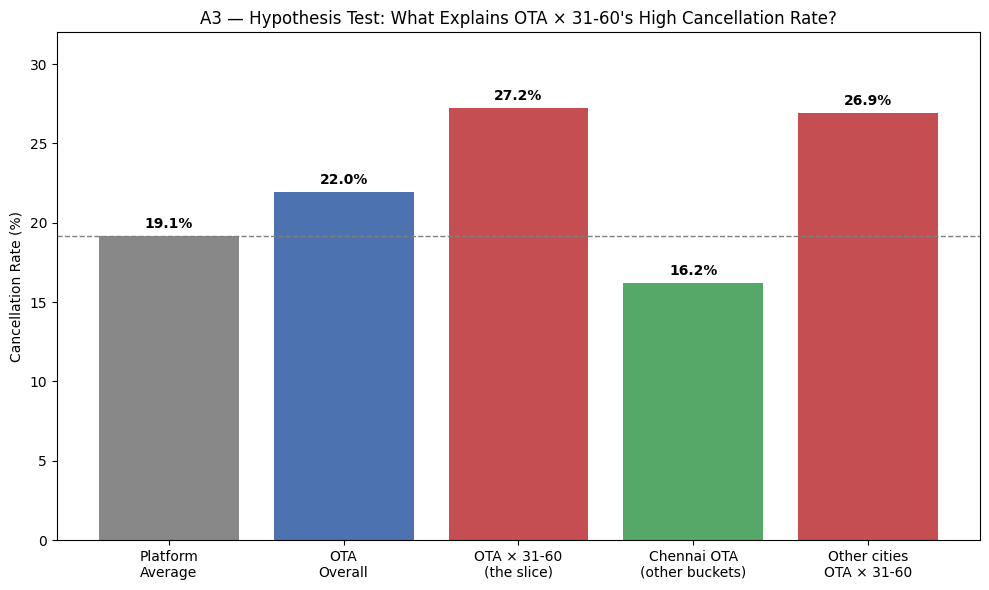

In [19]:
import matplotlib.pyplot as plt

labels = [
    'Platform\nAverage',
    'OTA\nOverall',
    'OTA × 31-60\n(the slice)',
    'Chennai OTA\n(other buckets)',
    'Other cities\nOTA × 31-60'
]
values = [19.15, 21.96, 27.25, 16.22, 26.93]
colors = ['#888888', '#4C72B0', '#C44E52', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color=colors)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(y=19.15, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Cancellation Rate (%)')
ax.set_title('A3 — Hypothesis Test: What Explains OTA × 31-60\'s High Cancellation Rate?')
ax.set_ylim(0, 32)

plt.tight_layout()
plt.savefig('a3_hypothesis_comparison.png', dpi=150)
plt.show()

### A3 — Visualization: Hypothesis Test Comparison

This chart plots the cancellation rate across the key comparison points used to test the three
hypotheses in A3:

- **Platform average (19.15%)** — baseline reference
- **OTA overall (21.96%)** — OTA's own baseline, slightly above platform average
- **OTA × 31-60 days, the slice itself (27.25%)** — the worst-performing slice under investigation
- **Chennai OTA, other lead-time buckets (16.22%)** — tests whether Chennai itself is the problem; rate
  drops back near/below platform average, ruling out a Chennai-specific (city) effect
- **Other cities, OTA × 31-60 days (26.93%)** — tests whether removing Chennai changes the picture;
  rate stays nearly as high as the slice itself, confirming the effect is NOT city-specific

The pattern is visually clear: removing the lead-time window (Chennai, other buckets) brings the rate
back to normal, while removing the city (other cities, same bucket) does NOT — confirming the
OTA × 31-60-day interaction, not geography, is the true driver.

### A4 — Targeted Recommendation

**WHO:** OTA bookings with 31-60 day lead time — 943 bookings, 257 cancellations, 27.25% cancel rate
(the single worst-rate slice that is also high-volume, per A2/A3).

**WHAT:** A 15-20% non-refundable deposit collected at booking time, applied only to this slice
(OTA + 31-60 day lead time).

**QUANTIFIED IMPACT:**

Baseline numbers for this slice:
- Bookings: 943
- Current cancellations: 257
- Current rate: 27.25%

Target range for post-intervention rate: between platform average (19.15%) and OTA's own overall
baseline (21.96%) — a conservative, evidence-grounded range rather than an arbitrary guess.

- Lower bound: 943 × (27.25% − 21.96%) = 943 × 0.0529 ≈ **50 fewer cancellations**
- Upper bound: 943 × (27.25% − 19.15%) = 943 × 0.0810 ≈ **76 fewer cancellations**

Platform-wide denominator: 11,821 clean bookings, current total cancellations = 2,264 (19.15%).

- Lower bound impact: 50 / 11,821 ≈ **0.42 percentage points**
- Upper bound impact: 76 / 11,821 ≈ **0.64 percentage points**

**Expected platform-wide impact: approximately 0.4–0.6 percentage points** (cancellation rate moves
from 19.15% to roughly 18.5–18.7%).

This single intervention is insufficient alone to close the board's full 5pp gap (19.15% → 14%), since
this slice is only 943 of 11,821 bookings (~8.0% of volume). Reaching the full target would require
applying similar targeted interventions to the next-worst slices (e.g., Corporate Portal × 31-60, at
24.3%) in addition to this one.

**RISK:** A deposit requirement may suppress OTA conversion/bookings — the same price-sensitive,
comparison-shopping customer behavior that drives high cancellation may also make this segment
deposit-averse, trading a cancellation problem for an acquisition problem.

#section_3

#SQLite

In [14]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')
df.to_sql('bookings_flat', conn, index=False, if_exists='replace')

query = """
SELECT * FROM bookings_flat LIMIT 5
"""
result = pd.read_sql_query(query, conn)
result

,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date,review_rating_normalized,lead_time,lead_time_bucket
0,100000,424,Customer_424,Group,2023-07-03 00:00:00,Manali,Platinum,38,Crimson Courtyard,Manali,...,0.00,NONE,46467.68,Debit Card,Cancelled,NaN,None,NaN,90,60+
1,100001,239,Customer_239,Individual,2022-07-18 00:00:00,Jaipur,None,32,Saffron Palace,Pune,...,0.00,None,16086.48,Net Banking,Cancelled,NaN,None,NaN,25,8-30
2,100002,301,Customer_301,Corporate,2023-07-05 00:00:00,Jaipur,Gold,53,Saffron Heights,Chennai,...,15373.35,SAVE10,90605.31,Net Banking,Completed,NaN,None,NaN,7,0-7
3,100003,722,Customer_722,Individual,2022-11-07 00:00:00,Udaipur,None,43,Indigo Lodge,Bangalore,...,0.00,NONE,17657.55,Credit Card,No-Show,NaN,None,NaN,25,8-30
4,100004,306,Customer_306,Corporate,2022-02-02 00:00:00,Udaipur,Silver,29,Cedar Lodge,Kochi,...,5924.82,SAVE10,80867.34,Credit Card,Completed,6.0,2024-11-21 00:00:00,3.0,15,8-30


In [15]:
cursor = conn.cursor()

schema_sql = """
CREATE TABLE customers (
    customer_id INTEGER PRIMARY KEY,
    customer_name VARCHAR(100) NOT NULL,
    customer_segment VARCHAR(20) NOT NULL CHECK (customer_segment IN ('Individual', 'Group', 'Corporate')),
    customer_signup_date DATE NOT NULL,
    customer_home_city VARCHAR(50),
    customer_loyalty_tier VARCHAR(20) NOT NULL DEFAULT 'None'
        CHECK (customer_loyalty_tier IN ('None', 'Silver', 'Gold', 'Platinum'))
);

CREATE TABLE properties (
    property_id INTEGER PRIMARY KEY,
    property_name VARCHAR(100) NOT NULL,
    property_city VARCHAR(50) NOT NULL,
    property_star_rating INTEGER CHECK (property_star_rating BETWEEN 1 AND 5),
    property_type VARCHAR(30) NOT NULL,
    property_total_rooms INTEGER CHECK (property_total_rooms > 0),
    UNIQUE (property_name, property_city, property_id)
);

CREATE TABLE bookings (
    booking_id INTEGER PRIMARY KEY,
    customer_id INTEGER NOT NULL REFERENCES customers(customer_id),
    property_id INTEGER NOT NULL REFERENCES properties(property_id),
    booking_date DATE NOT NULL,
    checkin_date DATE NOT NULL,
    checkout_date DATE NOT NULL,
    room_type VARCHAR(30),
    num_rooms INTEGER NOT NULL CHECK (num_rooms > 0),
    nights INTEGER NOT NULL CHECK (nights > 0),
    booking_channel VARCHAR(20) NOT NULL
        CHECK (booking_channel IN ('Direct Website', 'OTA', 'Travel Agent', 'Corporate Portal')),
    adr DECIMAL(10,2) NOT NULL CHECK (adr >= 0),
    discount_amount DECIMAL(10,2) DEFAULT 0 CHECK (discount_amount >= 0),
    coupon_code VARCHAR(20),
    total_amount DECIMAL(12,2) NOT NULL CHECK (total_amount >= 0),
    payment_method VARCHAR(30),
    booking_status VARCHAR(20) NOT NULL
        CHECK (booking_status IN ('Completed', 'Cancelled', 'No-Show')),
    CHECK (checkout_date > checkin_date)
);

CREATE TABLE reviews (
    review_id INTEGER PRIMARY KEY,
    booking_id INTEGER NOT NULL UNIQUE REFERENCES bookings(booking_id),
    review_rating DECIMAL(3,1) NOT NULL,
    review_date DATE NOT NULL
);
"""

cursor.executescript(schema_sql)
conn.commit()
print("Schema created successfully")

Schema created successfully


In [16]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
print(cursor.fetchall())

[('bookings_flat',), ('customers',), ('properties',), ('bookings',), ('reviews',)]


A-Q1: Highest Realized Revenue per City (RANK() over property_id, Completed bookings only)

In [17]:
query_a_q1 = """
WITH property_revenue AS (
    SELECT
        property_id,
        property_name,
        property_city,
        SUM(total_amount) AS revenue
    FROM bookings_flat
    WHERE booking_status = 'Completed'
    GROUP BY property_id, property_name, property_city
),
ranked AS (
    SELECT
        property_id,
        property_name,
        property_city,
        revenue,
        RANK() OVER (PARTITION BY property_city ORDER BY revenue DESC) AS rnk
    FROM property_revenue
)
SELECT property_city, property_id, property_name, revenue
FROM ranked
WHERE rnk = 1
ORDER BY property_city
"""

result_a_q1 = pd.read_sql_query(query_a_q1, conn)
print(result_a_q1)

  property_city  property_id     property_name      revenue
0     Bangalore            2   The Grand Plaza  13957983.73
1       Chennai           53   Saffron Heights  14355166.46
2         Delhi           49     Mango Retreat   4200186.89
3           Goa           23  Sapphire Retreat  19619575.91
4        Jaipur           30     Ivory Retreat   1805426.61
5         Kochi            1   The Grand Plaza   6631787.86
6        Manali           10       Lotus Manor   4347636.54
7        Mumbai           11      Coral Palace  10719830.16
8          Pune           34     Velvet Palace   6062114.47
9       Udaipur            6       Hilltop Inn  15669688.12


### A-Q1 — Highest Realized Revenue per City

For each property_city, identifies the property with the highest realized revenue using
RANK() OVER (PARTITION BY property_city ORDER BY revenue DESC). Revenue computed only from
Completed bookings (Footnote 8) and grouped by property_id (Footnote 4 — property_name alone
is unsafe since names repeat across cities with different IDs, e.g. "The Grand Plaza" appears
in both Bangalore and Kochi as two distinct properties).

#A-Q2: Average gap between consecutive bookings per customer, using LAG()

In [18]:
query_a_q2 = """
WITH completed_ordered AS (
    SELECT
        customer_id,
        checkin_date,
        LAG(checkin_date) OVER (PARTITION BY customer_id ORDER BY checkin_date) AS prev_checkin
    FROM bookings_flat
    WHERE booking_status = 'Completed'
),
gaps AS (
    SELECT
        customer_id,
        julianday(checkin_date) - julianday(prev_checkin) AS gap_days
    FROM completed_ordered
    WHERE prev_checkin IS NOT NULL
),
customer_avg_gap AS (
    SELECT
        customer_id,
        AVG(gap_days) AS avg_gap
    FROM gaps
    GROUP BY customer_id
)
SELECT COUNT(*) AS customers_under_30_day_avg_gap
FROM customer_avg_gap
WHERE avg_gap < 30
"""

result_a_q2 = pd.read_sql_query(query_a_q2, conn)
print(result_a_q2)

   customers_under_30_day_avg_gap
0                             445


### A-Q2 — Customers with Average Booking Gap Under 30 Days

For each customer, used LAG() OVER (PARTITION BY customer_id ORDER BY checkin_date) restricted to
booking_status = 'Completed' bookings, to find the previous check-in date for every booking. Computed
the gap in days between consecutive bookings, then averaged the gap per customer. Counted customers
whose average gap is under 30 days.

**Dialect note:** Query written and executed in SQLite (via Python's sqlite3 + pandas, against the
flat CSV loaded as table `bookings_flat`). SQLite has no native date-subtraction operator, so
julianday() was used to convert dates to numeric day values before subtracting
(julianday(checkin_date) - julianday(prev_checkin)). In PostgreSQL/MySQL, this would simply be
checkin_date - prev_checkin.

**Scope note:** Only customers with 2+ Completed bookings are included in this calculation by
construction — a customer with 0 or 1 Completed bookings has no gap to compute (LAG() returns NULL
for their first/only booking, which is filtered out via "WHERE prev_checkin IS NOT NULL").

**Answer: 445 customers** have an average gap under 30 days between consecutive Completed bookings.